In [22]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import datasets
import numpy as np

In [23]:
# 1️. 載入數據集
iris = datasets.load_iris()
X = iris.data[:, [0, 1]]      # 只取花萼長、花萼寬
y = iris.target
X = X[y != 2]  # 移除第3類 (維吉尼亞鳶尾)
y = y[y != 2]  # 移除第3類的標籤(留下0:setosa 1:versicolor)
X_train, X_test, y_train, y_test = train_test_split(        # 切分訓練集、測試集
     X, y, test_size=0.3, random_state=42, stratify=y)
# 數據標準化
sc = StandardScaler()
X_train_std=sc.fit_transform(X_train)
X_test_std = sc.fit_transform(X_test)

In [24]:
svm = SVC(kernel='linear', C=1.0, random_state=42)     # 大 C 值逼近硬間隔
svm.fit(X_train_std, y_train)

# print(svm.get_params())
print(svm.dual_coef_)
print(svm.support_vectors_)
print(svm.intercept_)

[[-0.52407859 -1.         -1.         -0.99715159  0.00106269  0.47364152
   1.          0.04652596  1.          1.        ]]
[[-0.10809166  0.64252941]
 [-1.5267947  -1.556349  ]
 [ 0.04954201  0.84242744]
 [-0.73862634 -0.15706274]
 [ 0.20717568 -0.35696078]
 [ 0.68007669  0.24273333]
 [-0.423359   -0.75675686]
 [ 0.36480935 -0.15706274]
 [ 0.20717568 -0.15706274]
 [-0.58099267 -1.15655293]]
[0.11428261]


In [25]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 用於正常顯示中文標籤
plt.rcParams['axes.unicode_minus'] = False  # 用於正常顯示負號(若有負數資料)
def plot_decision_regions(X, y,classifier, margin_set=None,resolution=0.02):
    
    # 標記與顏色
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    legend_labels=['Class -1 (Setosa)','Class 1 (Versicolor)']

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx],
                    label=legend_labels[cl], 
                    edgecolor='black',
                    s=20)
    if  margin_set is not None:
        plt.scatter(x=margin_set[:,0], 
                    y=margin_set[:,1],
                    alpha=0.5,
                    linewidth=1, 
                    color=colors[2],
                    marker=markers[2],
                    edgecolor='black',                    
                    label='support vectors',
                    s=80)
    # 分類決策區
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.2, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.xlabel('萼片長 (已標準化)')
    plt.ylabel('萼片寬 (已標準化)')
    plt.title('SVM 決策邊界最大化')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # 類別樣本
    

C:\Users\styeh\AppData\Local\Temp\ipykernel_18160\539516795.py:14: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


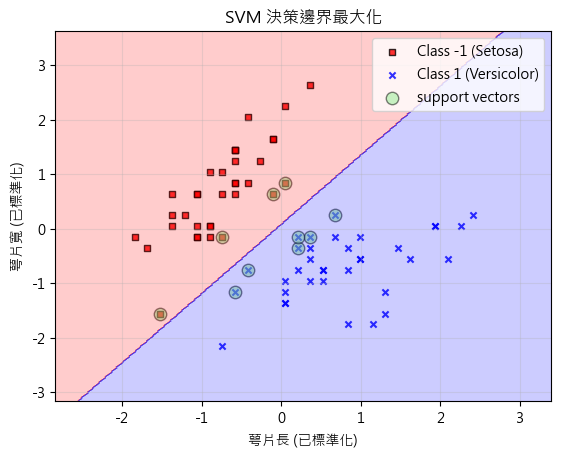

In [26]:
plot_decision_regions(X_train_std, 
                      y_train,
                      margin_set=svm.support_vectors_,
                      classifier=svm)

In [27]:
# 載入函式庫
from scipy.optimize import minimize
import numpy as np

In [76]:
# 2. 自訂線性核SVM類別
class LinearSVM:
    def __init__(self,randomState=1,tolerance=1e-5):
        self.res_=None
        self.tolerance_=tolerance
        self.randomState_=randomState
    # 訓練階段
    def fit(self,X,y,C):
        self.X_=X
        self.y_=y
        rgen = np.random.RandomState(self.randomState_)
        # 起始lambda向量(ndarray)，在[0,C]之間隨機產生len(y)個element
        lambda_init=rgen.uniform(0,C,size=len(y))   # 產生m筆樣本的初始lambda
        n_samples=len(y)    # 總樣本數
        cons=[]
        con = {'type': 'eq', 'fun': self._g,'args': (y,)}   # 等式限制條件
        cons.append(con)
        # 依據目標函數(fun)、限制條件(constraints)、優化邊界值(bounds)等進行優化
        self.res_=minimize(fun=self._f,x0=lambda_init,method='SLSQP',
             args=(y, X),bounds=self._constraint_bounds(n_samples,C),constraints=cons)
        if self.res_.success:
            self.all_lambda=self.res_.x     # 優化結果每一樣本的lambda
            self._extract_support_vectors(X,y)  # 依據每一樣本的lambda計算支持向量
            self._compute_w_and_b(X,y)      # 依據每一樣本的lambda計算w與b
            print("優化成功！")
            print(f"迭代次數: {self.res_.nit}")
            print(f"最終目標函數值: {self.res_.fun:.6f}")
            # print(sv_lambda)
            # print(f"最終lambda: {sv_lambda:.6f}")
        else:
            print("優化失敗:", self.res_.message)
    # 定義目標函數 (svm 對偶問題，求極小)
    def _f(self,l,y,X):   # l: lambda X: 特徵矩陣 y:標籤向量
        # 計算二次項
        K = np.dot(X, X.T)  # 線性核
        quadratic = 0.5 * np.sum(np.outer(l * y, l * y) * K)    # 目標函數第一項
        
        # 計算線性項: -sum(lambda_i)
        linear = -np.sum(l)     # m筆樣本的lambda加總，目標函數第二項
        
        # 總目標函數 (要最小化)
        objective = quadratic + linear
        return objective
        # 等價於
        # return 0.5*((l*y).T.dot(X).T.dot((l*y).T.dot(X)))-sum(l)
    # 定義約束條件
    def _g(self,l,y):   # l: lambda y:標籤向量
        return sum(l*y)
    # 邊界限制
    def _constraint_bounds(self,n_samples,C=None):  # 每一個lambda的限制範圍(min,max)
        return [(0, C) for _ in range(n_samples)]
    # 提取支持向量
    def _extract_support_vectors(self, X, y):
        self.sv_indices = np.where(self.all_lambda > self.tolerance_)[0]        
        self.sv_X = X[self.sv_indices]
        self.sv_y = y[self.sv_indices]
        self.sv_lambda = self.all_lambda[self.sv_indices]
    # 計算權重 w 和偏置 b
    def _compute_w_and_b(self,X,y):
        # 計算 w
        self.w=X.T.dot(self.all_lambda*y)
        # 等價於
        # self.w = np.sum(self.all_lambda.reshape(-1, 1) * y.reshape(-1, 1) * X, axis=0)
        sv_w=self.sv_X.T.dot(self.sv_lambda*self.sv_y)
        self.b=np.mean(self.sv_y-self.sv_X.dot(sv_w))
    # 輸入值與權重的線性組合
    def z(self,X):  
        return np.dot(X,self.w)
    # 使用訓練後的SVM參數進行預測
    def predict(self,X):
        return np.sign(self.z(X) + self.b)    

In [77]:
# 3. 進行訓練
y_train_01=np.where(y_train==0,-1,1)    # y part(0,1) 改為 (-1,1)
lsvm=LinearSVM(randomState=42)
lsvm.fit(X=X_train_std,y=y_train_01,C=1.0)
# 4. 評估準確程度
from sklearn.metrics import accuracy_score
y_pred=lsvm.predict(X_train_std)
print('accuracy: %.3f' % accuracy_score(y_train_01, y_pred))

優化成功！
迭代次數: 13
最終目標函數值: -4.378351
accuracy: 1.000


In [89]:
# 繪製SVM 的決策邊界和間隔
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 用於正常顯示中文標籤
plt.rcParams['axes.unicode_minus'] = False  # 用於正常顯示負號(若有負數資料)
def plot_decision_boundary_1(X, y, w, b, sv_indices):    
    # plt.figure(figsize=(10, 8))
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # 繪製數據點(紅色、藍色區分類別)   
    plt.scatter(X[y == -1, 0], X[y == -1, 1],
                c=colors[0], marker='o', label='Class -1 (Setosa)', alpha=0.6)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], 
                c=colors[1], marker='s', label='Class 1 (Versicolor)', alpha=0.6)
    
    # 標記支持向量(加黑色邊框)
    plt.scatter(X[sv_indices, 0], X[sv_indices, 1],
                s=20, linewidth=2, facecolors='none', 
                edgecolors='black',label='Support Vectors')
    
    # 繪製決策邊界
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),    #   xx.shape=(200,200) yy.shape=(200,200)
                         np.linspace(y_min, y_max, 200))
    
    # 計算網格點的決策函數值
    # Z = np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b    # 為每一個配對的點計算預測值
    Z = lsvm.z(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 繪製決策邊界和間隔
    plt.contour(xx, yy, Z, levels=[-1, 0, 1],   # 只畫等高線[-1, 0, 1]
                cmap=cmap,
                # colors=['blue', 'black', 'red'], 
                linestyles=['--', '-', '--'], 
                linewidths=[1, 2, 1])    
    plt.contourf(xx, yy, Z, levels=[Z.min(),0,Z.max()],     # 等高線[Z.min(),0,Z.max()]之間填滿
                 cmap=cmap, 
                #  colors=['lightblue', 'lightcoral'], 
                 alpha=0.3)
    
    plt.xlabel('萼片長 (已標準化)')
    plt.ylabel('萼片寬 (已標準化)')
    plt.title('SVM 決策邊界最大化')
    plt.legend()
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.grid(True, alpha=0.3)
    plt.show()

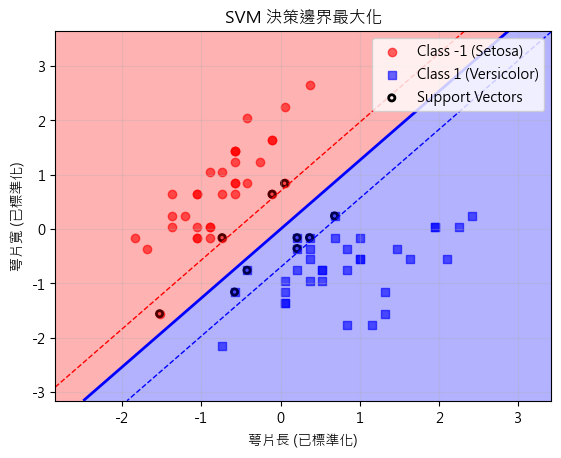

In [87]:
plot_decision_boundary_1(X_train_std, y_train_01, lsvm.w, lsvm.b, lsvm.sv_indices)

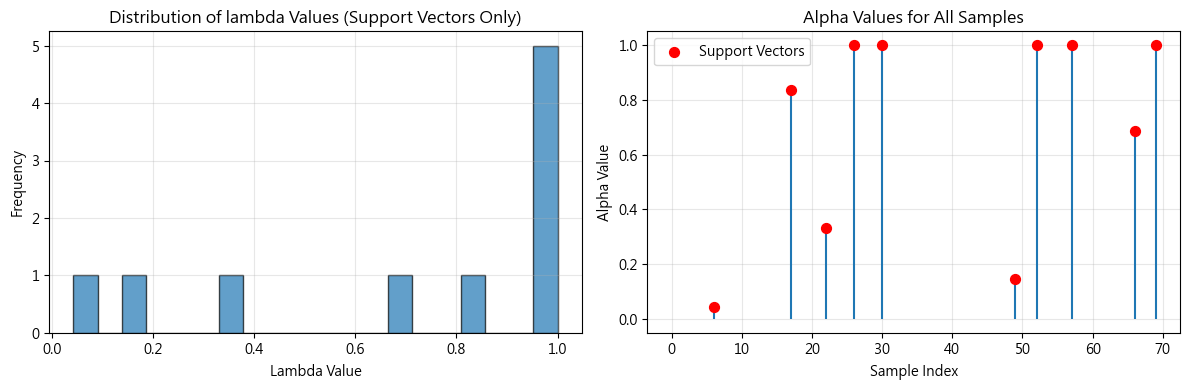


lambda 統計:
  最大值: 1.0000
  最小值: 0.0000
  平均值: 0.1006
  標準差: 0.2827

支持向量按類別:
  類別 -1: 4 個
  類別 1: 6 個


In [17]:
def analyze_alphas(lambdas, y, X, sv_indices):
    """
    分析 alpha 值的分佈
    """
    plt.figure(figsize=(12, 4))
    
    # 繪製 alpha 值的直方圖
    plt.subplot(1, 2, 1)
    plt.hist(lambdas[lambdas > 1e-5], bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel('Lambda Value')
    plt.ylabel('Frequency')
    plt.title('Distribution of lambda Values (Support Vectors Only)')
    plt.grid(True, alpha=0.3)
    
    # 繪製 alpha 值按索引排序
    plt.subplot(1, 2, 2)
    plt.stem(range(len(lambdas)), lambdas, markerfmt=' ', basefmt=" ")
    plt.scatter(sv_indices, lambdas[sv_indices], c='red', s=50, 
                label='Support Vectors', zorder=5)
    plt.xlabel('Sample Index')
    plt.ylabel('Alpha Value')
    plt.title('Alpha Values for All Samples')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 統計資訊
    print(f"\nlambda 統計:")
    print(f"  最大值: {np.max(lambdas):.4f}")
    print(f"  最小值: {np.min(lambdas):.4f}")
    print(f"  平均值: {np.mean(lambdas):.4f}")
    print(f"  標準差: {np.std(lambdas):.4f}")
    
    # 按類別分析支持向量
    sv_class_minus1 = sum(lsvm.sv_y == -1)
    sv_class_1 = sum(lsvm.sv_y == 1)
    print(f"\n支持向量按類別:")
    print(f"  類別 -1: {sv_class_minus1} 個")
    print(f"  類別 1: {sv_class_1} 個")

analyze_alphas(lsvm.all_lambda, y=y_train_01, X=X_train_std,sv_indices=lsvm.sv_indices)

In [18]:
print("=== 與 sklearn SVM 比較 ===")
print(f"自實作 SVM - w: {lsvm.w}")
print(f"sklearn SVM - w: {svm.coef_[0]}")
print(f"\n自實作 SVM - b: {lsvm.b:.4f}")
print(f"sklearn SVM - b: {svm.intercept_[0]:.4f}")

# 比較支持向量
sklearn_sv_indices = svm.support_
print(f"\n自實作 SVM 支持向量索引: {sorted(lsvm.sv_indices)}")
print(f"sklearn SVM 支持向量索引: {sorted(sklearn_sv_indices)}")

# 比較預測準確率
y_pred_sklearn = svm.predict(X_train_std)
accuracy_sklearn = np.mean(y_pred_sklearn == y_train)
y_pred=lsvm.predict(X_train_std)
print(f"\n自實作 SVM 準確率: {accuracy_score(y_train_01, y_pred)*100:.2f}%")
print(f"sklearn SVM 準確率: {accuracy_sklearn*100:.2f}%")

=== 與 sklearn SVM 比較 ===
自實作 SVM - w: [ 1.81266585 -1.42916511]
sklearn SVM - w: [ 1.81255348 -1.42928976]

自實作 SVM - b: 0.1715
sklearn SVM - b: 0.1143

自實作 SVM 支持向量索引: [np.int64(6), np.int64(17), np.int64(22), np.int64(26), np.int64(30), np.int64(49), np.int64(52), np.int64(57), np.int64(66), np.int64(69)]
sklearn SVM 支持向量索引: [np.int32(6), np.int32(17), np.int32(22), np.int32(26), np.int32(30), np.int32(49), np.int32(52), np.int32(57), np.int32(66), np.int32(69)]

自實作 SVM 準確率: 100.00%
sklearn SVM 準確率: 100.00%
